In [1]:
print("Hello ,Task 3!")

Hello ,Task 3!


In [2]:
import pandas as pd


In [3]:

data = {
    'Channel': ['Organic Search', 'Social Media', 'Email Campaign', 'Paid Ads', 'Direct Traffic'],
    'Visitors': [10000, 8000, 5000, 6000, 4000],
    'Signups': [2000, 1200, 1500, 900, 800],
    'Leads': [500, 240, 600, 180, 160],
    'Customers': [100, 48, 150, 36, 40]
}

df = pd.DataFrame(data)
print(df)

          Channel  Visitors  Signups  Leads  Customers
0  Organic Search     10000     2000    500        100
1    Social Media      8000     1200    240         48
2  Email Campaign      5000     1500    600        150
3        Paid Ads      6000      900    180         36
4  Direct Traffic      4000      800    160         40


In [4]:
df['Visitor_to_Signup'] = (df['Signups'] / df['Visitors']) * 100
df['Signup_to_Lead'] = (df['Leads'] / df['Signups']) * 100
df['Lead_to_Customer'] = (df['Customers'] / df['Leads']) * 100
df['Overall_Conversion'] = (df['Customers'] / df['Visitors']) * 100

print(df[['Channel', 'Visitor_to_Signup', 'Signup_to_Lead', 'Lead_to_Customer', 'Overall_Conversion']])

          Channel  Visitor_to_Signup  Signup_to_Lead  Lead_to_Customer  \
0  Organic Search               20.0            25.0              20.0   
1    Social Media               15.0            20.0              20.0   
2  Email Campaign               30.0            40.0              25.0   
3        Paid Ads               15.0            20.0              20.0   
4  Direct Traffic               20.0            20.0              25.0   

   Overall_Conversion  
0                 1.0  
1                 0.6  
2                 3.0  
3                 0.6  
4                 1.0  


In [5]:
total_visitors = df['Visitors'].sum()
total_signups = df['Signups'].sum()
total_leads = df['Leads'].sum()
total_customers = df['Customers'].sum()

print(f"Total Visitors: {total_visitors:,}")
print(f"Total Signups: {total_signups:,} ({ (total_signups/total_visitors)*100:.1f}%)")
print(f"Total Leads: {total_leads:,} ({ (total_leads/total_signups)*100:.1f}% of signups)")
print(f"Total Customers: {total_customers:,} ({ (total_customers/total_leads)*100:.1f}% of leads)")
print(f"\nOverall Conversion Rate: {(total_customers/total_visitors)*100:.1f}%")

Total Visitors: 33,000
Total Signups: 6,400 (19.4%)
Total Leads: 1,680 (26.2% of signups)
Total Customers: 374 (22.3% of leads)

Overall Conversion Rate: 1.1%


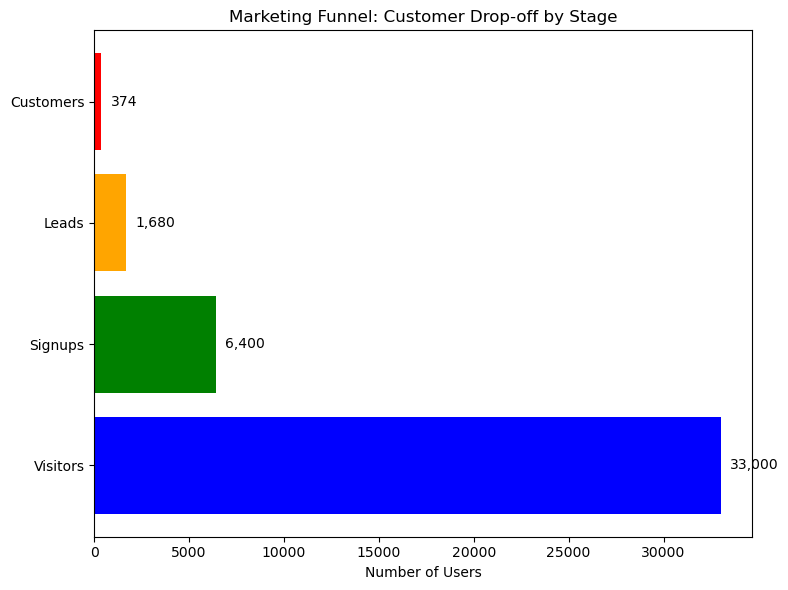

In [6]:
import matplotlib.pyplot as plt

stages = ['Visitors', 'Signups', 'Leads', 'Customers']
values = [total_visitors, total_signups, total_leads, total_customers]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(stages, values, color=['blue', 'green', 'orange', 'red'])

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
            f'{val:,}', va='center')

ax.set_xlabel('Number of Users')
ax.set_title('Marketing Funnel: Customer Drop-off by Stage')
plt.tight_layout()
plt.show()

In [7]:
best_channel = df.loc[df['Overall_Conversion'].idxmax()]
worst_channel = df.loc[df['Overall_Conversion'].idxmin()]

print("=" * 40)
print("BEST PERFORMING CHANNEL")
print("=" * 40)
print(f"Channel: {best_channel['Channel']}")
print(f"Overall Conversion: {best_channel['Overall_Conversion']:.1f}%")
print(f"Visitors: {best_channel['Visitors']:,} → Customers: {best_channel['Customers']:,}")
print(f"Signup Rate: {best_channel['Visitor_to_Signup']:.1f}%")
print(f"Lead Rate: {best_channel['Signup_to_Lead']:.1f}%")
print(f"Closing Rate: {best_channel['Lead_to_Customer']:.1f}%")

print("\n" + "=" * 40)
print("WORST PERFORMING CHANNEL")
print("=" * 40)
print(f"Channel: {worst_channel['Channel']}")
print(f"Overall Conversion: {worst_channel['Overall_Conversion']:.1f}%")
print(f"Visitors: {worst_channel['Visitors']:,} → Customers: {worst_channel['Customers']:,}")

print("\n" + "=" * 40)
print("CHANNEL RANKING (Best to Worst)")
print("=" * 40)
df_sorted = df.sort_values('Overall_Conversion', ascending=False)
for i, row in df_sorted.iterrows():
    print(f"{i+1}. {row['Channel']}: {row['Overall_Conversion']:.1f}% conversion")

BEST PERFORMING CHANNEL
Channel: Email Campaign
Overall Conversion: 3.0%
Visitors: 5,000 → Customers: 150
Signup Rate: 30.0%
Lead Rate: 40.0%
Closing Rate: 25.0%

WORST PERFORMING CHANNEL
Channel: Social Media
Overall Conversion: 0.6%
Visitors: 8,000 → Customers: 48

CHANNEL RANKING (Best to Worst)
3. Email Campaign: 3.0% conversion
1. Organic Search: 1.0% conversion
5. Direct Traffic: 1.0% conversion
2. Social Media: 0.6% conversion
4. Paid Ads: 0.6% conversion


## MARKETING FUNNEL ANALYSIS - KEY INSIGHTS

### Summary
- Total Visitors: 33,000
- Total Customers: 374
- Overall Conversion Rate: 1.1%

---

### Funnel Drop-Off Analysis

| Stage | Loss | Insight |
|-------|------|---------|
| Visitors → Signups | 80.6% | **Biggest problem** - Landing page or offer not compelling |
| Signups → Leads | 73.8% | Lead nurturing needs improvement |
| Leads → Customers | 77.7% | Sales follow-up is weak |

---

### Channel Performance Ranking

1. **Email Campaign** (3.0% conversion) - BEST
2. Organic Search (1.0% conversion)
3. Direct Traffic (1.0% conversion)
4. Social Media (0.6% conversion)
5. **Paid Ads** (0.6% conversion) - WORST

---

### Key Takeaways

1. **Email Campaign is the star** - 3x better than average
2. **Paid Ads are losing money** - 6,000 visitors → only 36 customers
3. **Visitor → Signup is the critical drop-off** - Fix this first
4. **Social Media underperforms** - Needs creative refresh

---

## RECOMMENDATIONS

### Immediate Actions (Next 30 days)

1. **Stop or reduce Paid Ads spend** - Worst ROI at 0.6% conversion

2. **Double down on Email Campaign**:
   - Increase email acquisition budget
   - Test subject lines and offers

3. **Fix the signup page**:
   - A/B test headline and CTA button
   - Remove unnecessary form fields
   - Add social proof and testimonials

### Medium-Term Actions (60-90 days)

4. **Improve lead nurturing** (73.8% drop signup → lead):
   - Implement automated email sequences
   - Retarget non-converting signups

5. **Strengthen sales follow-up** (77.7% drop lead → customer):
   - Reduce response time to under 2 hours
   - Add phone follow-up for hot leads

6. **Refresh Social Media strategy**:
   - Test TikTok/Reels content
   - Partner with micro-influencers

---

### Expected Impact

| Action | Expected Improvement |
|--------|---------------------|
| Fix signup page | 20-30% more signups |
| Improve lead nurturing | 15-20% more leads → customers |
| Cut Paid Ads | Save 15-20% of marketing budget |

**Potential new customer increase: 50-80 customers per month**

---

*Analysis completed for Future Interns - Data Science & Analytics*
*Task 3: Marketing Funnel & Conversion Performance Analysis*